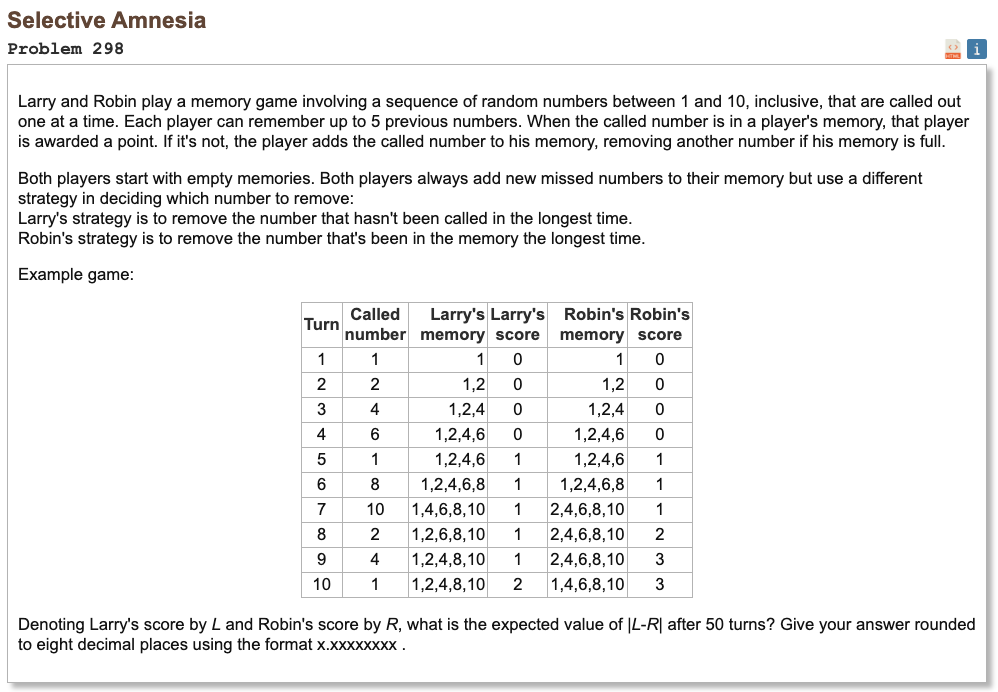

## Initial approach

* the key is that the actual called values do not matter, only how the two memories overlap and in what order each player stores them
* Larry and Robin treat hits differently, so the state must keep Larry’s recency order and Robin’s insertion order
* many concrete games are really the same after renaming the stored numbers, so canonically relabel each state and merge equivalent cases
* from any state, a future call can only be one of the numbers already present in at least one memory, or one of the remaining unseen values, so each step has only a small number of distinct transitions
* run a dynamic program over turns, state, and current score gap between Larry and Robin
* each transition changes the score gap by minus one, zero, or plus one, depending on who scores on that call
* after 50 turns, add up the absolute score gap weighted by its probability over all final states
* this compressed state approach is small enough to run directly and gives the required rounded value

In [1]:
from collections import defaultdict

def canonical_state(larry, robin):
    mapping = {}
    next_label = 0

    def relabel(seq):
        nonlocal next_label
        out = []
        for x in seq:
            if x not in mapping:
                mapping[x] = next_label
                next_label += 1
            out.append(mapping[x])
        return tuple(out)

    return relabel(larry), relabel(robin)

def apply_call(state, value):
    larry, robin = state
    larry = list(larry)
    robin = list(robin)

    larry_hit = value in larry
    robin_hit = value in robin
    delta = (1 if larry_hit else 0) - (1 if robin_hit else 0)

    if larry_hit:
        idx = larry.index(value)
        x = larry.pop(idx)
        larry.append(x)
    else:
        if len(larry) == 5:
            larry.pop(0)
        larry.append(value)

    if not robin_hit:
        if len(robin) == 5:
            robin.pop(0)
        robin.append(value)

    return canonical_state(tuple(larry), tuple(robin)), delta

def transitions(state):
    larry, robin = state
    used = sorted(set(larry) | set(robin))
    grouped = defaultdict(int)

    for value in used:
        next_state, delta = apply_call(state, value)
        grouped[(next_state, delta)] += 1

    fresh_count = 10 - len(used)
    if fresh_count > 0:
        fresh_value = max(used, default=-1) + 1
        next_state, delta = apply_call(state, fresh_value)
        grouped[(next_state, delta)] += fresh_count

    return [(count, next_state, delta) for (next_state, delta), count in grouped.items()]

def solve(turns):
    current = defaultdict(float)
    current[(((), ()), 0)] = 1.0

    for _ in range(turns):
        nxt = defaultdict(float)
        for (state, diff), prob in current.items():
            for count, next_state, delta in transitions(state):
                nxt[(next_state, diff + delta)] += prob * count / 10.0
        current = nxt

    result = 0.0
    for (_, diff), prob in current.items():
        result += abs(diff) * prob

    return result

In [2]:
%%time
result = solve(50)
print("Result:", format(result, ".8f"))

Result: 1.76882294
CPU times: user 4.99 s, sys: 31.8 ms, total: 5.02 s
Wall time: 5.03 s
